# Exploratory Data Analysis (EDA) on Global Superstore Dataset

## Objective

The objective of this project is to perform exploratory data analysis (EDA) on the Global Superstore dataset to identify trends, patterns, and business insights related to sales, profit, customer segments, product performance, and regional markets.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Kaggle Notebooks

## Dataset

The dataset contains over 51,000 sales transactions from a global retail company, including information on products, customers, orders, sales, profit, shipping, and geographic regions.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anandaramg/global-superstore/Global Superstore.txt


# Exploratpry Data Analysis (EDA) on Global Superstore Sales Data

## Project Overview

This Project Explores the Global Superstore Dataset to uncover trends in sales, profitability, customer behaviour, and regional performance. Through data cleaning,visualization, and analysis, the project aims to provide actionale business insights that can help improve sales strategiers and operational decision-making.

## objective

The main objectives of this analysis are to:

- Understand the structure and quality of the dataset.
- Analyze sales and profit across categories and sub-categories.
- Identify the most profitable products and customer segments.
- Explore regional and country-level sales performance.
- Investigate the impact of discounts on profitability.
- Examine shipping methods and delivery times.
- Provide business recommendations based on the findings.

In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots within the notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")

# Display all columns if needed
pd.set_option("display.max_columns", None)


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/anandaramg/global-superstore/Global Superstore.txt


In [4]:
df = pd.read_csv('/kaggle/input/datasets/anandaramg/global-superstore/Global Superstore.txt',sep="\t")

## Data Inspection

Before performing exploratory data analysis, it is important to inspect the dataset to understand its structure, identify potential data quality issues, and verify that the data has been loaded correctly.

In [5]:
# DIsplay the first 5 rows
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,记录数,Order Date,Order ID,Order Priority,Product ID,Product Name,Profit,Quantity,Region,Row ID,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
#display the last 5 rows
df.tail()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,记录数,Order Date,Order ID,Order Priority,Product ID,Product Name,Profit,Quantity,Region,Row ID,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
51285,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,High,OFF-BI-10000632,Satellite Sectional Post Binders,22.5732,2,West,33646,69,Corporate,2014-12-04 00:00:00.000,Same Day,5.15,California,Binders,2014,North America,49
51286,Office Supplies,Los Angeles,United States,AM-103604,Alice McCarthy,0.2,US,1,2014-12-03 00:00:00.000,CA-2014-109701,High,OFF-BI-10004187,Staples,3.1584,6,West,33645,9,Corporate,2014-12-04 00:00:00.000,Same Day,0.44,California,Binders,2014,North America,49
51287,Office Supplies,Los Angeles,United States,HR-147704,Hallie Redmond,0.2,US,1,2014-12-18 00:00:00.000,CA-2014-106964,Medium,OFF-BI-10000320,GBC Plastic Binding Combs,4.2804,2,West,32321,12,Home Office,2014-12-21 00:00:00.000,First Class,0.31,California,Binders,2014,North America,51
51288,Office Supplies,Los Angeles,United States,RM-196754,Robert Marley,0.2,US,1,2014-12-25 00:00:00.000,CA-2014-145219,Critical,OFF-BI-10001670,Vinyl Sectional Post Binders,33.9300,3,West,35917,90,Home Office,2014-12-26 00:00:00.000,First Class,15.95,California,Binders,2014,North America,52
51289,Office Supplies,Los Angeles,United States,FH-143654,Fred Hopkins,0.2,US,1,2014-12-26 00:00:00.000,CA-2014-121398,Medium,OFF-BI-10001718,GBC DocuBind P50 Personal Binding Machine,51.8238,3,West,37371,154,Corporate,2014-12-30 00:00:00.000,Standard Class,9.59,California,Binders,2014,North America,52


In [7]:
# Number of rows and columns
df.shape


(51290, 27)

In [8]:
#list all coumn names
df.columns

Index(['Category', 'City', 'Country', 'Customer ID', 'Customer Name',
       'Discount', 'Market', '记录数', 'Order Date', 'Order ID', 'Order Priority',
       'Product ID', 'Product Name', 'Profit', 'Quantity', 'Region', 'Row ID',
       'Sales', 'Segment', 'Ship Date', 'Ship Mode', 'Shipping Cost', 'State',
       'Sub-Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [9]:
# Data types and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer ID     51290 non-null  object 
 4   Customer Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order Date      51290 non-null  object 
 9   Order ID        51290 non-null  object 
 10  Order Priority  51290 non-null  object 
 11  Product ID      51290 non-null  object 
 12  Product Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [10]:
# Summary statistics for numerical coloumns
df.describe()


,Discount,记录数,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [11]:
# Check for missing values
df.isnull().sum()

Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
记录数               0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
Product Name      0
Profit            0
Quantity          0
Region            0
Row ID            0
Sales             0
Segment           0
Ship Date         0
Ship Mode         0
Shipping Cost     0
State             0
Sub-Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [12]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Check data types
df.dtypes

Category           object
City               object
Country            object
Customer ID        object
Customer Name      object
Discount          float64
Market             object
记录数                 int64
Order Date         object
Order ID           object
Order Priority     object
Product ID         object
Product Name       object
Profit            float64
Quantity            int64
Region             object
Row ID              int64
Sales               int64
Segment            object
Ship Date          object
Ship Mode          object
Shipping Cost     float64
State              object
Sub-Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

In [14]:
# Convert data columns to datetime format
df["Order Date"] = pd.to_datetime(df["Ship Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Customer ID     51290 non-null  object        
 4   Customer Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  object        
 7   记录数             51290 non-null  int64         
 8   Order Date      51290 non-null  datetime64[ns]
 9   Order ID        51290 non-null  object        
 10  Order Priority  51290 non-null  object        
 11  Product ID      51290 non-null  object        
 12  Product Name    51290 non-null  object        
 13  Profit          51290 non-null  float64       
 14  Quantity        51290 non-null  int64         
 15  Re

In [16]:
df["记录数"].value_counts()

记录数
1    51290
Name: count, dtype: int64

In [17]:
df.drop(columns=["记录数", "Row ID"], inplace=True)

In [18]:
# Month name
df["Month"] = df["Order Date"].dt.month_name()

#Quarter
df["Quarter"] = df["Order Date"].dt.quarter

# Shipping time
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days


In [19]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,Order Date,Order ID,Order Priority,Product ID,Product Name,Profit,Quantity,Region,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum,Month,Quarter,Shipping Days
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2011-01-09,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2,January,1,0
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2011-01-26,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4,January,1,0
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-09,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32,August,3,0
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2011-08-09,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32,August,3,0
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2011-10-03,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40,October,4,0


# Exploratory Data Analysis

The following analyses aim to answer key business questions related to sales performance, profitability, customer behavior, and operational efficiency.

## Business Question 1

**Which product categories generate the highest total sales?**

Understanding category-level sales helps identify the company's primary revenue drivers and supports decisions related to inventory management and marketing.

In [20]:
# Total sales by category
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales


Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64

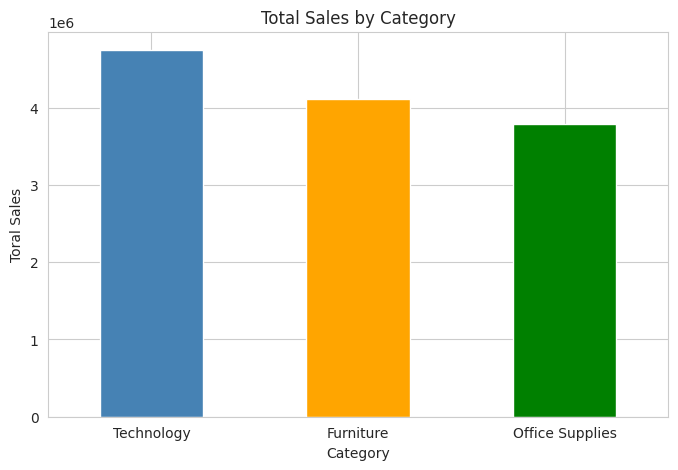

In [21]:
plt.figure(figsize=(8,5))

category_sales.plot(
    kind = "bar",
    color=["steelblue","orange","green"]
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Toral Sales")

plt.xticks(rotation=0)

plt.show()


### Interpretation

Technology generated the highest total sales among all product categories, indicating that it is the company's primary revenue source.

Office Supplies generated the lowest total sales, suggesting lower customer demand or lower-priced products compared to the other categories.

### Business Recommendation

- Continue investing in Technology products through marketing and inventory management.
- Investigate why Office Supplies underperforms and identify opportunities to increase sales through promotions or product bundling.

## Business Question 2: Which product categories generate the highest profit?

While sales measure revenue, profit measures the actual earnings generated by each category. Analyzing profit helps identify which product categories contribute the most to the company's financial success.

In [22]:
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64

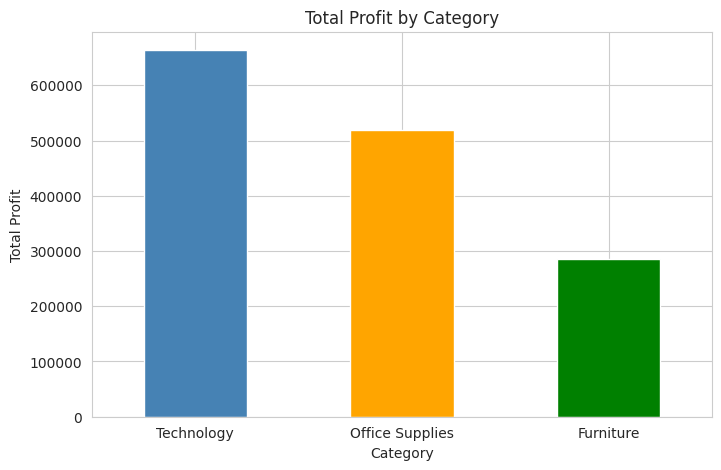

In [23]:
plt.figure(figsize=(8,5))

category_profit.plot(
    kind="bar",
    color=["steelblue", "orange", "green"]
)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=0)

plt.show()


### Interpretation

The analysis shows that **Technology** is the most profitable product category, making it the largest contributor to the company's overall profit.

Although **Furniture** generates relatively high sales, it contributes the lowest total profit among the three categories. This suggests that higher costs, larger discounts, or lower profit margins may be affecting its profitability.

**Office Supplies** falls between Technology and Furniture in terms of total profit, indicating a balanced contribution to the company's earnings.

### Business Recommendation

- Continue investing in the Technology category through targeted marketing and inventory planning, as it generates both high sales and high profit.
- Review the pricing and discount strategy for Furniture products to understand why profitability is lower despite relatively strong sales.
- Maintain the performance of Office Supplies while identifying opportunities to improve its profit margins.

## Business Question 3: Which sub-categories generate the highest sales?

Categories provide a broad overview of business performance. However, analyzing sales at the sub-category level provides more detailed insights into which product groups contribute most to overall revenue.

Understanding sub-category performance helps the business prioritize inventory, marketing campaigns, and product investments.

In [24]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales


Sub-Category
Phones         1706874
Copiers        1509439
Chairs         1501682
Bookcases      1466559
Storage        1127124
Appliances     1011081
Machines        779071
Tables          757034
Accessories     749307
Binders         461952
Furnishings     385609
Art             372163
Paper           244307
Supplies        243090
Envelopes       170926
Fasteners        83254
Labels           73433
Name: Sales, dtype: int64

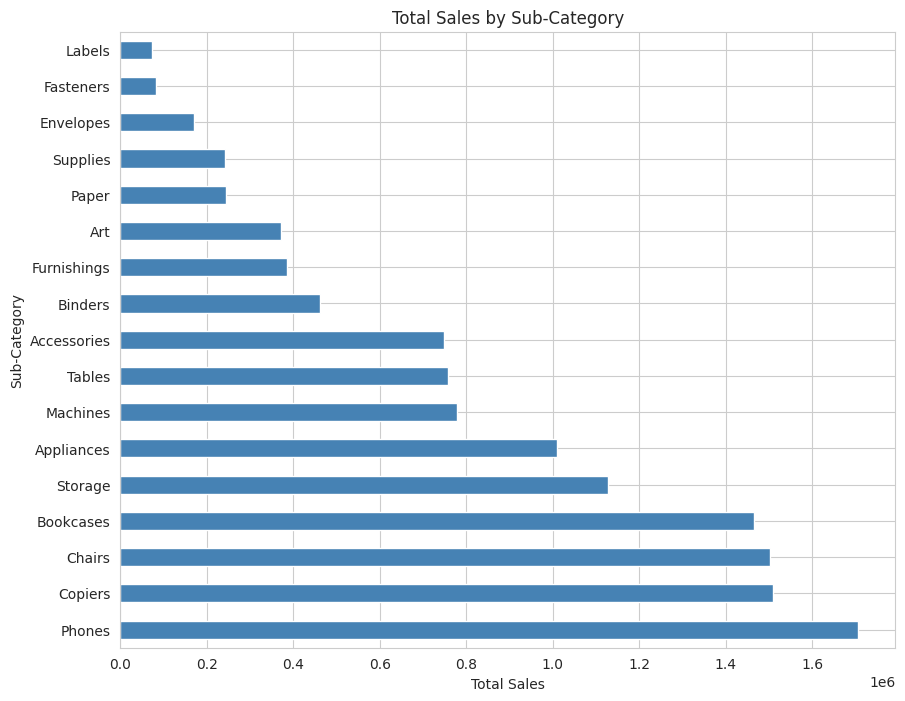

In [25]:
plt.figure(figsize=(10,8))

subcategory_sales.plot(
    kind="barh",
    color="steelblue"

)

plt.title("Total Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.show()


### Interpretation

The analysis shows that **Phones** is the highest-selling sub-category, making it the largest contributor to overall sales revenue. This indicates strong customer demand and highlights Phones as a key product group for the business.

In contrast, **Labels** generates the lowest total sales, suggesting relatively low customer demand or a limited market compared with other sub-categories.

These findings provide a more detailed understanding of sales performance than the broader category-level analysis and can help guide inventory management and marketing strategies.

### Business Recommendation

- Continue investing in the Phones sub-category by maintaining sufficient inventory and supporting it with targeted marketing campaigns.
- Review the performance of the Labels sub-category to determine whether sales can be improved through promotions, pricing adjustments, or product expansion.
- Allocate resources toward high-performing sub-categories while monitoring consistently low-performing products.

## Business Question 4: Which sub-categories generate the highest profit?

Sales alone do not indicate business success. Profitability analysis helps identify which sub-categories contribute the most to overall earnings and highlights areas that may require pricing or cost improvements.

In [26]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

subcategory_profit


Sub-Category
Copiers        258567.54818
Phones         216717.00580
Bookcases      161924.41950
Appliances     141680.58940
Chairs         140396.26750
Accessories    129626.30620
Storage        108461.48980
Binders         72449.84600
Paper           59207.68270
Machines        58867.87300
Art             57953.91090
Furnishings     46967.42550
Envelopes       29601.11630
Supplies        22583.26310
Labels          15010.51200
Fasteners       11525.42410
Tables         -64083.38870
Name: Profit, dtype: float64

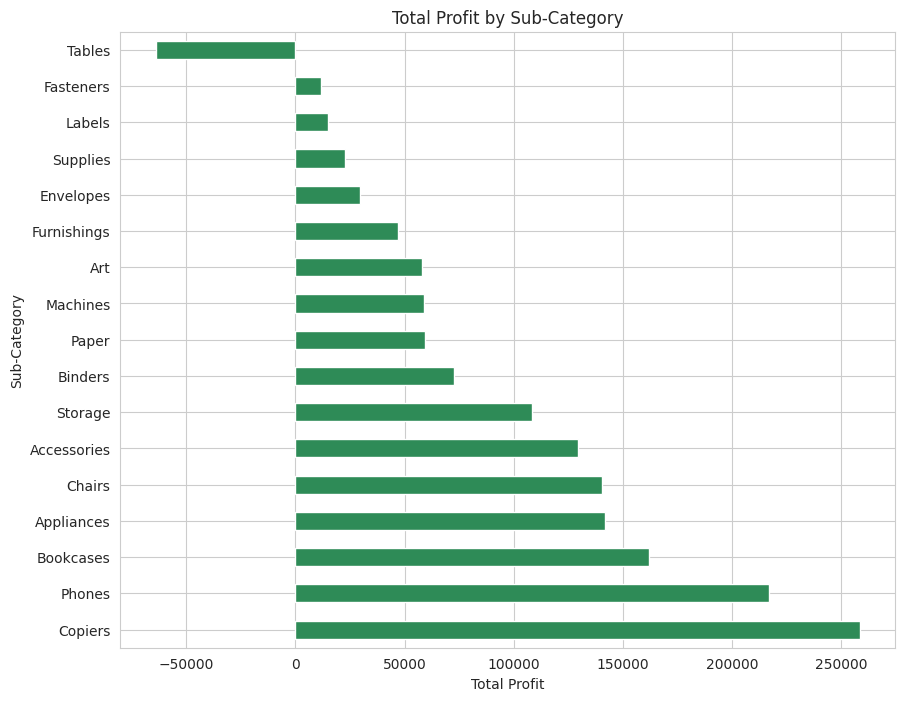

In [27]:
plt.figure(figsize=(10,8))

subcategory_profit.plot(
    kind="barh",
    color="seagreen"
    
)

plt.title("Total Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.show()


### Interpretation

The profitability analysis reveals that **Copiers** generate the highest total profit, making them the most valuable sub-category from an earnings perspective.

Although **Phones** recorded the highest sales, they rank second in terms of total profit. This suggests that strong sales do not always translate into the highest profitability.

Most notably, the **Tables** sub-category has a negative total profit, indicating that the company is losing money on these products. This may be due to high discounts, increased costs, or low profit margins.

These findings highlight the importance of evaluating both sales and profit when assessing business performance.

### Business Recommendation

- Continue investing in the Copiers sub-category, as it delivers the highest contribution to profit.
- Maintain the strong sales performance of Phones while exploring opportunities to improve profit margins.
- Investigate the Tables sub-category to determine the causes of its negative profitability. Potential actions include reviewing pricing, reducing discounts, renegotiating supplier costs, or discontinuing consistently unprofitable products.

## Business Question 5: Which regions generate the highest sales?

Understanding sales performance across different regions helps identify the company's strongest markets and areas with growth potential.

Regional analysis enables businesses to allocate resources more effectively, optimize marketing strategies, and make informed expansion decisions.

In [28]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales


Region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: Sales, dtype: int64

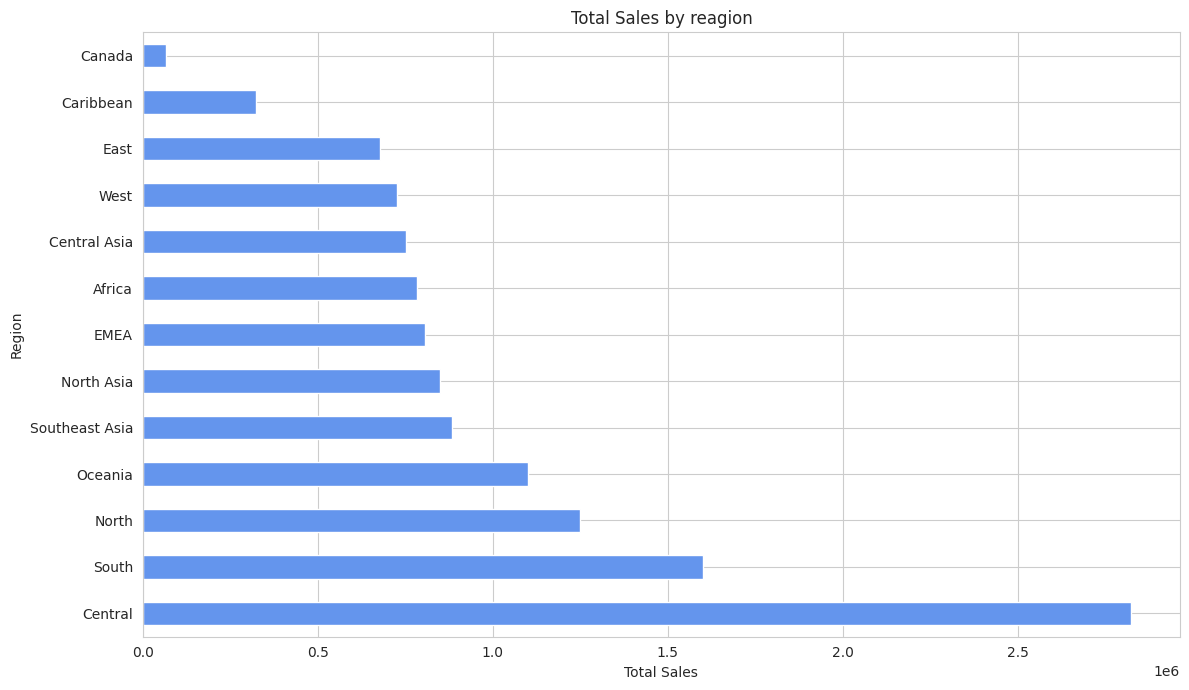

In [29]:
plt.figure(figsize=(12,7))

region_sales.plot(
    kind ="barh",
    color ="cornflowerblue"
)

plt.title("Total Sales by reagion")
plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.tight_layout()

plt.show()



### Interpretation

The **Central** region generated the highest total sales, with approximately **2.82 million** in revenue, making it the company's strongest-performing market.

The **South** and **North** regions also contributed significantly to overall sales, indicating strong customer demand in these markets.

On the other hand, **Canada** generated the lowest total sales, with approximately **66.9 thousand** in revenue. This may reflect a smaller market size, lower customer demand, or limited business operations in the region.

### Business Recommendation

- Continue investing in the Central region by maintaining strong inventory levels and targeted marketing campaigns.
- Analyse the successful sales strategies used in the Central region and consider applying them to other high-potential regions.
- Investigate the factors contributing to Canada's low sales performance, including market size, product availability, and promotional efforts, to identify opportunities for growth.

## Business Question 6: Which countries generate the highest sales?

Country-level sales analysis provides a more detailed understanding of market performance. Identifying the highest and lowest revenue-generating countries helps businesses prioritize investments, allocate resources effectively, and identify opportunities for market expansion.

In [30]:
country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)


Country
United States     2297354
Australia          925257
France             858930
China              700591
Germany            628857
Mexico             622620
India              589664
United Kingdom     528570
Indonesia          404887
Brazil             361098
Name: Sales, dtype: int64

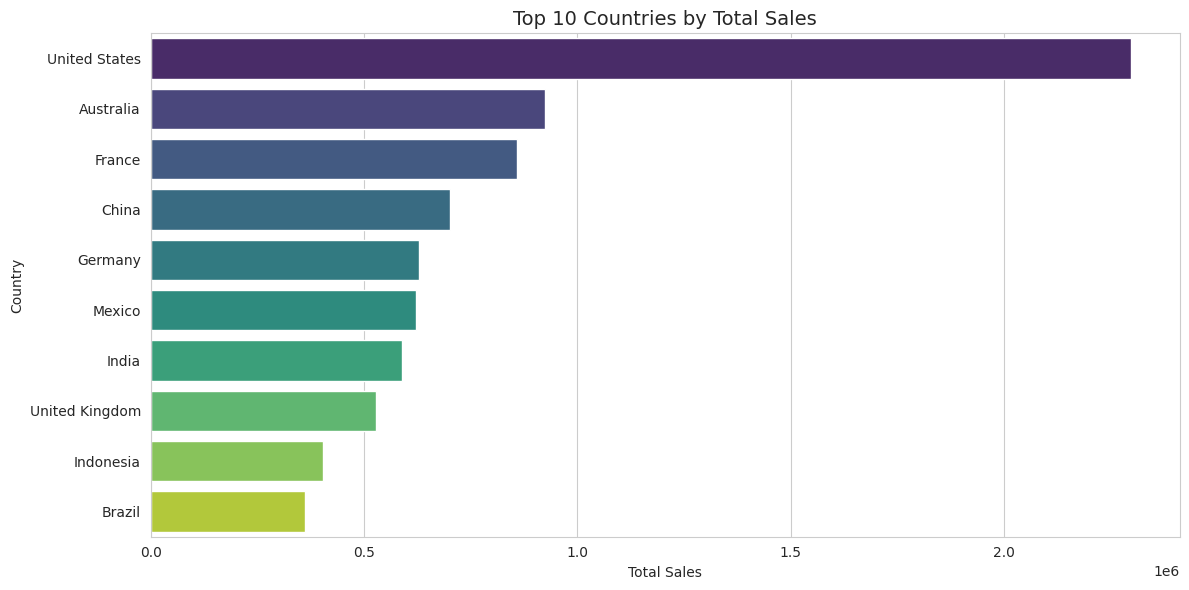

In [31]:
top10_countries = country_sales.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10_countries.values,
    y=top10_countries.index,
    hue=top10_countries.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Countries by Total Sales", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

### Interpretation

The country-level sales analysis shows that the **United States** is the company's largest market, generating approximately **2.30 million** in total sales. This significantly exceeds all other countries and highlights the importance of the U.S. market to the business.

**Australia** and **France** rank second and third, respectively, demonstrating strong sales performance and making them important international markets.

The remaining countries in the top ten, including **China**, **Germany**, **Mexico**, **India**, **United Kingdom**, **Indonesia**, and **Brazil**, also contribute substantially to global sales, indicating a well-diversified international customer base.

### Business Recommendation

- Continue strengthening the company's presence in the United States, as it is the primary source of revenue.
- Invest in high-performing international markets such as Australia and France to sustain future growth.
- Develop market-specific strategies for emerging markets like India, Indonesia, and Brazil to further increase sales and expand the customer base.

## Business Question 7: Which customer segment generates the highest sales and profit?

Customer segmentation helps businesses understand which groups contribute the most to revenue and profitability. This information supports targeted marketing strategies, customer relationship management, and resource allocation.

In [32]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       6508141
Corporate      3824808
Home Office    2309956
Name: Sales, dtype: int64

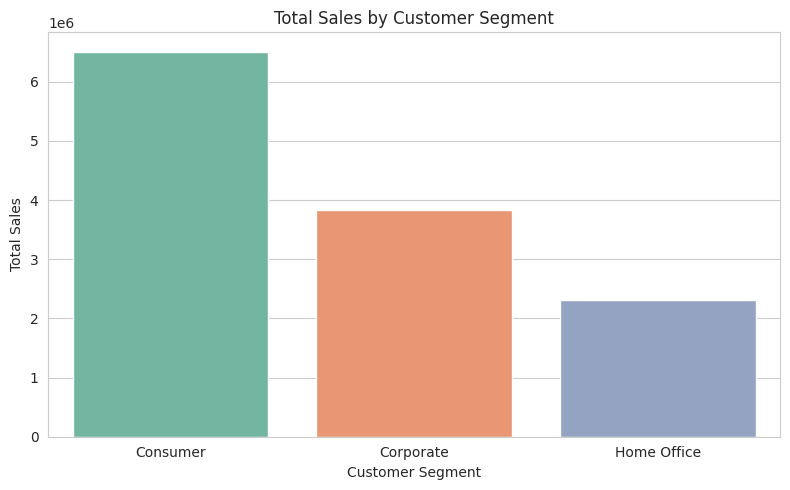

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values,
    hue=segment_sales.index,
    palette="Set2",
    legend=False
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

In [34]:
segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

segment_profit

Segment
Consumer       749239.78206
Corporate      441208.32866
Home Office    277009.18056
Name: Profit, dtype: float64

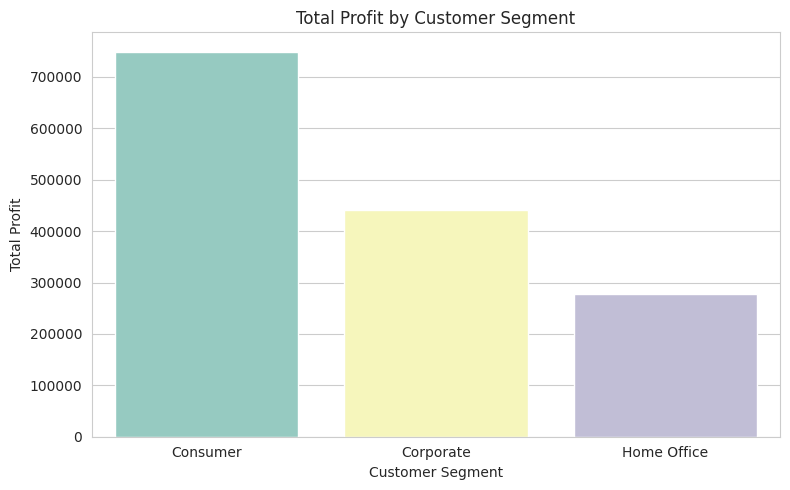

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_profit.index,
    y=segment_profit.values,
    hue=segment_profit.index,
    palette="Set3",
    legend=False
)

plt.title("Total Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.tight_layout()

plt.show()

### Interpretation

The customer segment analysis shows that the **Consumer** segment generates the highest total sales, contributing approximately **6.51 million** in revenue. It also generates the highest total profit, with approximately **749 thousand**, making it the company's most valuable customer segment.

The **Corporate** segment ranks second in both sales and profit, indicating that business customers are another important source of revenue.

The **Home Office** segment contributes the lowest sales and profit among the three segments. Although it represents a smaller share of the business, it still provides a positive contribution to overall profitability.

Overall, the results suggest that the company relies heavily on Consumer customers as its primary source of revenue and profit.

### Business Recommendation

- Continue investing in customer acquisition and retention strategies for the Consumer segment, as it is the company's largest contributor to both sales and profit.
- Strengthen relationships with Corporate customers through loyalty programmes and customised business solutions to encourage repeat purchases.
- Explore targeted marketing campaigns for the Home Office segment to identify opportunities for increasing sales while maintaining profitability.

## Business Question 8: How have sales changed over time?

Time series analysis helps identify trends, seasonal patterns, and changes in sales performance over time. Understanding these patterns enables businesses to forecast demand, optimize inventory, and plan marketing campaigns more effectively.

In [36]:
# Create a Year-Month column
df["Year_Month"] = df["Order Date"].dt.to_period("M")

In [37]:
monthly_sales = (
    df.groupby("Year_Month")["Sales"]
      .sum()
)

monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales

Year_Month
2011-01-01     86920
2011-02-01     96303
2011-03-01    134787
2011-04-01    121202
2011-05-01    139580
2011-06-01    207040
2011-07-01    132856
2011-08-01    192042
2011-09-01    271150
2011-10-01    227747
2011-11-01    289190
2011-12-01    323614
2012-01-01    160281
2012-02-01    101294
2012-03-01    157715
2012-04-01    157679
2012-05-01    200802
2012-06-01    246932
2012-07-01    170958
2012-08-01    264809
2012-09-01    307155
2012-10-01    260081
2012-11-01    306580
2012-12-01    342788
2013-01-01    212369
2013-02-01    167866
2013-03-01    204211
2013-04-01    176589
2013-05-01    221220
2013-06-01    403250
2013-07-01    260989
2013-08-01    304764
2013-09-01    383270
2013-10-01    294892
2013-11-01    338302
2013-12-01    422865
2014-01-01    254003
2014-02-01    193666
2014-03-01    264245
2014-04-01    243566
2014-05-01    273807
2014-06-01    396511
2014-07-01    268013
2014-08-01    449553
2014-09-01    475630
2014-10-01    424801
2014-11-01    533555
20

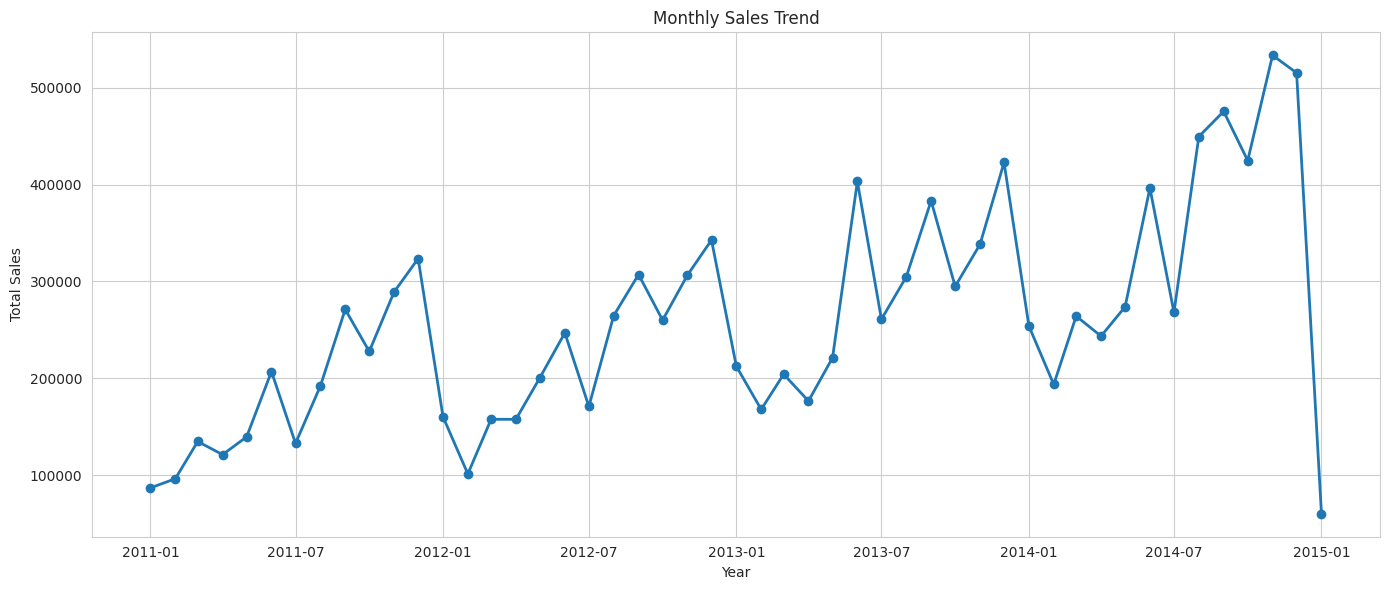

In [38]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

### Interpretation

The monthly sales trend shows an overall upward trend between **2011 and 2014**, indicating that the business experienced consistent growth over the four-year period.

Although monthly sales fluctuate, the general pattern suggests increasing revenue over time. Several months, particularly during **late 2013 and 2014**, recorded noticeably higher sales, exceeding **500,000**.

The sharp decline at the beginning of **2015** should not be interpreted as a business downturn. It most likely occurs because the dataset contains only a small portion of data for January 2015 rather than the entire month.

Overall, the analysis indicates positive business growth with recurring periods of high sales that may reflect seasonal demand.

### Business Recommendation

- Continue monitoring monthly sales trends to improve demand forecasting and inventory planning.
- Investigate the factors contributing to high-performing months and apply successful marketing or sales strategies to other periods.
- Consider seasonal demand patterns when planning promotions, staffing, and inventory levels.
- Exclude incomplete months from trend analysis when evaluating business performance to avoid misleading conclusions.

## Business Question 9: Does offering higher discounts reduce profit?

Discounts are commonly used to increase sales and attract customers. However, excessive discounts can reduce profit margins and even lead to financial losses.

This analysis explores the relationship between discount rates and profit to determine whether higher discounts negatively impact profitability.

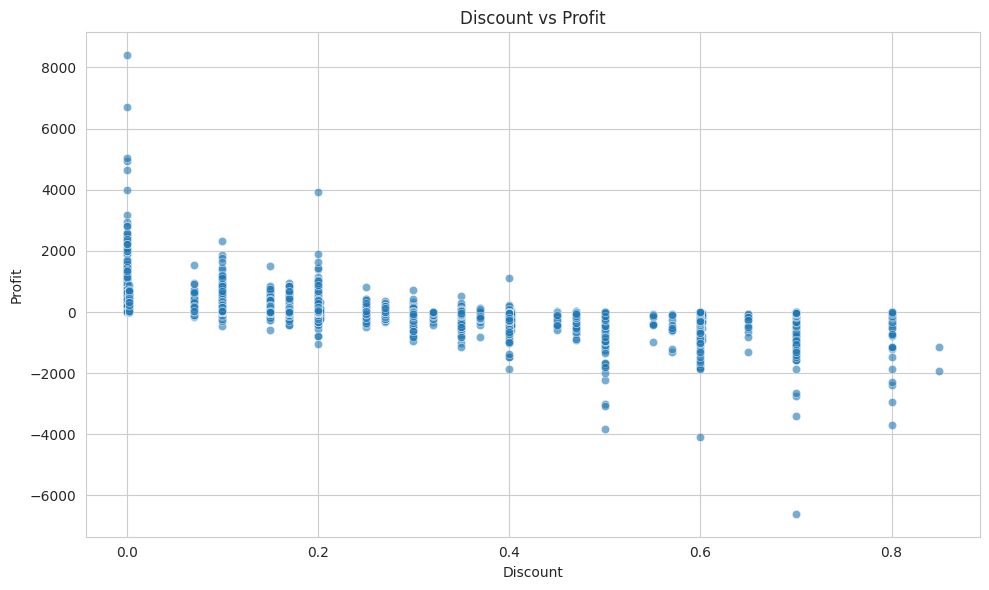

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.6
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()


In [40]:
correlation = df["Discount"].corr(df["Profit"])
print(f"Correlation between Discount and Profit: {correlation:.2f}")

Correlation between Discount and Profit: -0.32


### Interpretation

The scatter plot reveals a **negative relationship** between discount and profit. As the discount percentage increases, profits generally tend to decrease.

The calculated **correlation coefficient of -0.32** indicates a **moderate negative correlation** between the two variables. While the relationship is not perfectly linear, it suggests that higher discounts are often associated with lower profitability.

The plot also shows that many of the largest financial losses occur at discount levels between **50% and 80%**, indicating that excessive discounting may significantly reduce profit and, in some cases, result in losses.

These findings support the earlier observation that certain sub-categories, such as **Tables**, may be unprofitable due to aggressive discounting.

### Business Recommendation

- Review the company's discount strategy to ensure that discounts do not significantly reduce profit margins.
- Limit excessive discounts on low-margin products, particularly those that consistently generate losses.
- Consider offering targeted or promotional discounts instead of blanket discounts across all products.
- Conduct further analysis on unprofitable sub-categories, such as Tables, to determine whether pricing, supplier costs, or discount policies should be revised.

## Business Question 10: Which shipping mode is used most frequently?

Shipping is an important part of the customer experience and business operations. Analysing shipping modes helps identify customer preferences and supports decisions related to logistics, delivery efficiency, and operational planning.

In [41]:
ship_mode_count = (
    df["Ship Mode"]
      .value_counts()
)

ship_mode_count

Ship Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64

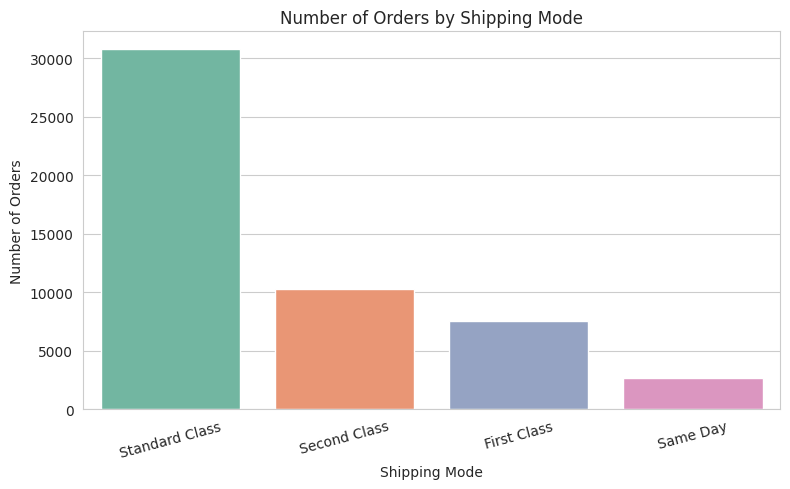

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=ship_mode_count.index,
    y=ship_mode_count.values,
    hue=ship_mode_count.index,
    palette="Set2",
    legend=False
)

plt.title("Number of Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

### Interpretation

The analysis shows that **Standard Class** is by far the most frequently used shipping mode, accounting for the majority of customer orders.

**Second Class** is the second most commonly used shipping option, followed by **First Class**.

**Same Day** delivery is the least frequently used shipping mode, suggesting that relatively few customers require or choose expedited shipping.

Overall, the results indicate that customers generally prefer cost-effective standard shipping over faster delivery options.

### Business Recommendation

- Continue optimizing the Standard Class shipping process, as it handles the largest share of customer orders.
- Ensure sufficient logistics capacity to maintain efficient delivery times for Standard Class shipments.
- Evaluate customer demand for premium shipping options and consider promotional campaigns to encourage the use of faster delivery services where appropriate.
- Monitor delivery performance across all shipping modes to maintain high customer satisfaction.

## Business Question 11: Which products generate the highest sales?

Identifying the highest-selling products helps businesses understand customer demand at the product level. These insights support inventory management, marketing strategies, and product portfolio decisions.

In [43]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Apple Smart Phone, Full Size                                86936
Cisco Smart Phone, Full Size                                76441
Motorola Smart Phone, Full Size                             73159
Nokia Smart Phone, Full Size                                71904
Canon imageCLASS 2200 Advanced Copier                       61600
Hon Executive Leather Armchair, Adjustable                  58200
Office Star Executive Leather Armchair, Adjustable          50667
Harbour Creations Executive Leather Armchair, Adjustable    50120
Samsung Smart Phone, Cordless                               48654
Nokia Smart Phone, with Caller ID                           47880
Name: Sales, dtype: int64

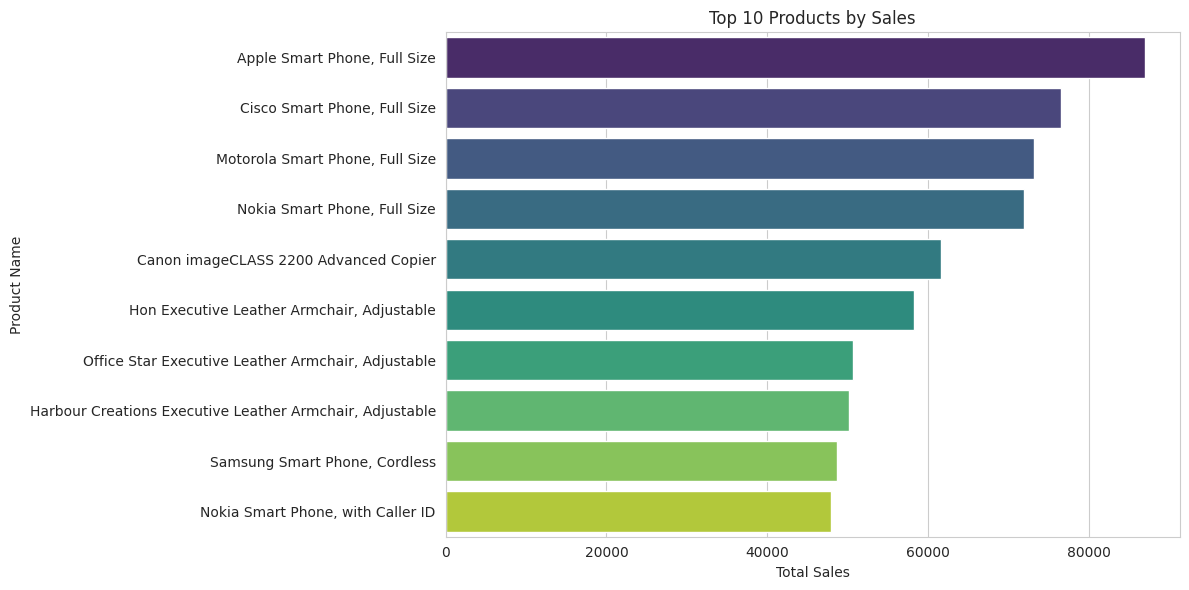

In [44]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    hue=top_products.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()

plt.show()

### Interpretation

The analysis identifies the **Apple Smart Phone, Full Size** as the highest-selling product, generating approximately **90,000** in total sales. Several other smartphone models, including **Cisco**, **Motorola**, and **Nokia**, also rank among the top-selling products, highlighting the strong customer demand for technology products.

In addition to smartphones, products such as the **Canon imageCLASS 2200 Advanced Copier** and premium executive leather armchairs appear in the top ten, indicating that both technology products and high-end office furniture contribute significantly to the company's overall revenue.

The concentration of smartphone products among the top-selling items reinforces earlier findings that **Technology** is the highest-performing product category and **Phones** are the leading sub-category.

### Business Recommendation

- Maintain adequate inventory levels for the highest-selling smartphone products to prevent stock shortages.
- Continue investing in marketing campaigns for top-performing technology products to sustain strong sales.
- Monitor the performance of premium office furniture and copier products, as they represent valuable sources of revenue.
- Regularly review the product portfolio to identify opportunities for expanding successful product lines and improving the performance of lower-selling products.

## Business Question 12: Which products generate the highest profit?

High sales do not necessarily translate into high profitability. Analysing product-level profit helps identify the products that contribute the most to the company's earnings and highlights products that create the greatest business value.

This analysis complements the previous sales analysis by comparing revenue generation with profitability.

In [45]:
top_profit_products = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_profit_products

Product Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64

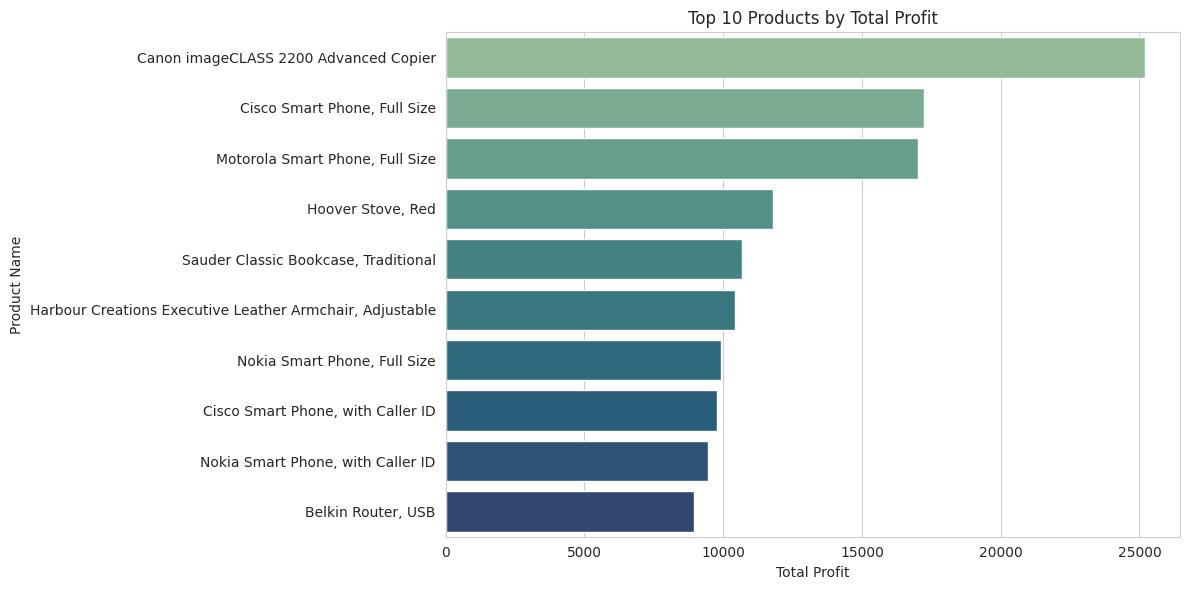

In [46]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_profit_products.values,
    y=top_profit_products.index,
    hue=top_profit_products.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Products by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")

plt.tight_layout()

plt.show()

### Interpretation

The product-level profit analysis shows that the **Canon imageCLASS 2200 Advanced Copier** generates the highest total profit among all products, making it the company's most profitable product.

In contrast, the **Belkin Router USB** records the lowest total profit, indicating that it contributes very little to the company's overall profitability.

Comparing this analysis with the previous sales analysis reveals an important business insight: **the highest-selling product is not necessarily the most profitable**. While the Apple Smart Phone generated the highest sales, the Canon copier generated the highest profit, demonstrating that strong revenue does not always translate into maximum profitability.

This finding highlights the importance of evaluating both sales and profit when assessing product performance.

### Business Recommendation

- Continue investing in and promoting the **Canon imageCLASS 2200 Advanced Copier**, as it is the company's highest-profit product and contributes significantly to overall profitability.
- Ensure adequate inventory levels for high-profit products to avoid stock shortages and lost sales opportunities.
- Investigate products with low profitability, such as the **Belkin Router USB**, to determine whether pricing, production costs, or discount strategies are affecting their performance.
- Evaluate the entire product portfolio regularly to identify products that consistently generate high profits and those that require improvement or replacement.
- Focus not only on increasing sales but also on maximizing profitability by prioritizing products with strong profit margins.

# Executive Summary

This project explored the Global Superstore dataset to identify key sales and profitability trends across products, customers, regions, and shipping methods. Through exploratory data analysis, several important business insights were discovered:

- Technology is the highest-performing category in terms of both sales and profit.
- Phones generate the highest sales among all sub-categories, while Copiers generate the highest profit.
- Tables recorded a negative overall profit despite generating sales, indicating potential pricing or discount issues.
- The Central region and the United States contribute the highest total sales.
- The Consumer segment is the company's largest source of both revenue and profit.
- Sales generally increased between 2011 and 2014, demonstrating positive business growth.
- Higher discounts are associated with lower profitability, with a moderate negative correlation between Discount and Profit.
- Standard Class is the most frequently used shipping mode.
- The Apple Smart Phone is the highest-selling product, while the Canon imageCLASS 2200 Advanced Copier is the most profitable product.

# Final Business Recommendations

Based on the analysis, the following recommendations are suggested:

- Continue investing in Technology products, as they generate the highest sales and profit.
- Review the pricing and discount strategy for Tables and other low-profit products to improve profitability.
- Focus marketing efforts on the Consumer segment, which contributes the largest share of revenue.
- Maintain strong business operations in high-performing markets such as the United States and the Central region while exploring growth opportunities in emerging markets.
- Monitor discount policies carefully to avoid excessive reductions that negatively affect profit margins.
- Ensure sufficient inventory for high-performing products, particularly smartphones and high-profit copier products.
- Continue improving the Standard Class shipping service, as it is the preferred shipping method for most customers.

# Conclusion

This exploratory data analysis provided valuable insights into the Global Superstore dataset by examining sales performance, profitability, customer segments, geographic markets, shipping methods, and product performance.

The analysis demonstrated that while high sales contribute to business growth, profitability depends on factors such as product mix and discount strategy. These findings can help support data-driven decision-making related to pricing, inventory management, marketing, and operational planning.

Overall, this project highlights how exploratory data analysis can transform raw business data into meaningful insights that support strategic business decisions.